In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

CHAR_DIR = BASE_PATH / "outputs" / "dataset_characterization"
MODEL_DIR = BASE_PATH / "outputs" / "densenet201_baseline"

OUT_DIR = BASE_PATH / "outputs" / "color_normalization_test"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_model.keras"

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]
IMG_SIZE = (250, 250)
BATCH_SIZE = 4

print("Model path:", MODEL_PATH)
print("Output folder:", OUT_DIR)

Model path: E:\Thesis\outputs\densenet201_baseline\best_model.keras
Output folder: E:\Thesis\outputs\color_normalization_test


In [3]:
summary = pd.read_csv(CHAR_DIR / "dataset_summary.csv")
print(summary[["dataset", "mean_r", "std_r", "mean_g", "std_g", "mean_b", "std_b"]])

ham_row = summary.loc[summary["dataset"] == "HAM10000"].iloc[0]
pad_row = summary.loc[summary["dataset"] == "PAD_UFES_20"].iloc[0]

ham_mean_rgb = np.array([ham_row["mean_r"], ham_row["mean_g"], ham_row["mean_b"]], dtype=np.float32)
ham_std_rgb  = np.array([ham_row["std_r"],  ham_row["std_g"],  ham_row["std_b"]],  dtype=np.float32)

pad_mean_rgb = np.array([pad_row["mean_r"], pad_row["mean_g"], pad_row["mean_b"]], dtype=np.float32)
pad_std_rgb  = np.array([pad_row["std_r"],  pad_row["std_g"],  pad_row["std_b"]],  dtype=np.float32)

print("HAM mean RGB:", ham_mean_rgb)
print("HAM std RGB :", ham_std_rgb)
print("PAD mean RGB:", pad_mean_rgb)
print("PAD std RGB :", pad_std_rgb)

       dataset      mean_r      std_r      mean_g      std_g      mean_b  \
0     HAM10000  196.677987  24.752347  138.926531  22.273621  144.808617   
1  PAD_UFES_20  169.898708  26.212480  132.983700  23.253908  117.593489   

       std_b  
0  24.730965  
1  26.141327  
HAM mean RGB: [196.678   138.92653 144.80862]
HAM std RGB : [24.752346 22.27362  24.730965]
PAD mean RGB: [169.89871 132.9837  117.59349]
PAD std RGB : [26.21248  23.253908 26.141327]


In [4]:
pad = pd.read_csv(PAD_PATH / "metadata.csv")

PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print(pad_4["exists"].value_counts())
print(pad_4["label"].value_counts())

exists
True    1871
Name: count, dtype: int64
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [5]:
def normalize_color_match(image_path, out_path, src_mean, src_std, tgt_mean, tgt_std):
    """
    Match target image channel-wise mean/std to source dataset mean/std.
    """
    img = Image.open(image_path).convert("RGB")
    arr = np.array(img).astype(np.float32)

    out = np.zeros_like(arr, dtype=np.float32)
    eps = 1e-8

    for c in range(3):
        channel = arr[:, :, c]
        channel_norm = (channel - tgt_mean[c]) / (tgt_std[c] + eps)
        channel_out = channel_norm * src_std[c] + src_mean[c]
        out[:, :, c] = channel_out

    out = np.clip(out, 0, 255).astype(np.uint8)
    Image.fromarray(out).save(out_path)

In [6]:
NORMALIZED_DIR = OUT_DIR / "PAD_UFES_20_color_normalized_to_HAM"
NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)

normalized_paths = []

for _, row in pad_4.iterrows():
    original_path = row["image_path"]
    filename = os.path.basename(original_path)
    out_path = NORMALIZED_DIR / filename

    if not out_path.exists():
        normalize_color_match(
            image_path=original_path,
            out_path=out_path,
            src_mean=ham_mean_rgb,
            src_std=ham_std_rgb,
            tgt_mean=pad_mean_rgb,
            tgt_std=pad_std_rgb
        )

    normalized_paths.append(str(out_path))

pad_norm = pad_4.copy()
pad_norm["image_path"] = normalized_paths

print("Normalized images saved:", len(normalized_paths))
print(pad_norm[["img_id", "label", "image_path"]].head())

Normalized images saved: 1871
                  img_id label  \
0  PAT_1516_1765_530.png   NEV   
1     PAT_46_881_939.png   BCC   
2  PAT_1545_1867_547.png   ACK   
3  PAT_1989_4061_934.png   ACK   
4   PAT_684_1302_588.png   BCC   

                                          image_path  
0  E:\Thesis\outputs\color_normalization_test\PAD...  
1  E:\Thesis\outputs\color_normalization_test\PAD...  
2  E:\Thesis\outputs\color_normalization_test\PAD...  
3  E:\Thesis\outputs\color_normalization_test\PAD...  
4  E:\Thesis\outputs\color_normalization_test\PAD...  


In [7]:
def image_mean_rgb(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32)
    return arr[:, :, 0].mean(), arr[:, :, 1].mean(), arr[:, :, 2].mean()

sample_original = pad_4["image_path"].sample(5, random_state=42).tolist()
sample_norm = [str(NORMALIZED_DIR / os.path.basename(p)) for p in sample_original]

for o, n in zip(sample_original, sample_norm):
    o_rgb = image_mean_rgb(o)
    n_rgb = image_mean_rgb(n)
    print(
        os.path.basename(o),
        "original=", tuple(round(x, 2) for x in o_rgb),
        "normalized=", tuple(round(x, 2) for x in n_rgb)
    )

PAT_1571_2484_488.png original= (170.14, 141.96, 136.88) normalized= (196.38, 147.02, 162.57)
PAT_567_1076_545.png original= (206.44, 130.63, 123.03) normalized= (229.69, 136.17, 149.43)
PAT_46_880_140.png original= (162.72, 136.41, 131.14) normalized= (189.38, 141.76, 157.14)
PAT_545_1030_854.png original= (157.57, 147.15, 141.29) normalized= (184.51, 151.96, 166.75)
PAT_279_429_142.png original= (205.17, 131.16, 102.59) normalized= (227.95, 136.68, 130.11)


In [8]:
pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

pad_original_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

pad_norm_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_norm,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Original PAD samples:", pad_original_generator.samples)
print("Normalized PAD samples:", pad_norm_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Found 1871 validated image filenames belonging to 4 classes.
Original PAD samples: 1871
Normalized PAD samples: 1871


In [9]:
model = load_model(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

Loaded model: E:\Thesis\outputs\densenet201_baseline\best_model.keras


In [10]:
def evaluate_generator(model, generator):
    loss, acc = model.evaluate(generator, verbose=1)
    probs = model.predict(generator, verbose=1)
    preds = np.argmax(probs, axis=1)
    true = generator.classes
    return loss, acc, probs, preds, true

In [11]:
orig_loss, orig_acc, orig_probs, orig_preds, orig_true = evaluate_generator(
    model, pad_original_generator
)

print("Original PAD Accuracy:", orig_acc)
print("Original PAD Loss:", orig_loss)

468/468 [==============================] - 72s 146ms/step
Original PAD Accuracy: 0.2891501784324646
Original PAD Loss: 3.0000996589660645


In [12]:
norm_loss, norm_acc, norm_probs, norm_preds, norm_true = evaluate_generator(
    model, pad_norm_generator
)

print("Color-Normalized PAD Accuracy:", norm_acc)
print("Color-Normalized PAD Loss:", norm_loss)

468/468 [==============================] - 80s 171ms/step
Color-Normalized PAD Accuracy: 0.2912880778312683
Color-Normalized PAD Loss: 2.6812164783477783


In [13]:
def compute_metrics(true_classes, pred_classes, pred_probs, class_names):
    acc = accuracy_score(true_classes, pred_classes)
    prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
    rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
    f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

    true_onehot = to_categorical(true_classes, num_classes=len(class_names))
    auc = roc_auc_score(
        true_onehot,
        pred_probs,
        multi_class="ovr",
        average="macro"
    )

    report = classification_report(
        true_classes,
        pred_classes,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(true_classes, pred_classes)

    return acc, prec, rec, f1, auc, report, cm

In [14]:
orig_acc_m, orig_prec, orig_rec, orig_f1, orig_auc, orig_report, orig_cm = compute_metrics(
    orig_true, orig_preds, orig_probs, CLASS_NAMES
)

print("=== Original PAD ===")
print("Accuracy :", orig_acc_m)
print("Precision:", orig_prec)
print("Recall   :", orig_rec)
print("F1 Score :", orig_f1)
print("AUC      :", orig_auc)
print(orig_report)

=== Original PAD ===
Accuracy : 0.28915018706574025
Precision: 0.29792286744381263
Recall   : 0.34610476349299785
F1 Score : 0.21773694454600206
AUC      : 0.6664067795001829
              precision    recall  f1-score   support

         ACK       0.28      0.03      0.06       730
         BCC       0.68      0.34      0.45       845
         MEL       0.05      0.08      0.06        52
         NEV       0.18      0.94      0.30       244

    accuracy                           0.29      1871
   macro avg       0.30      0.35      0.22      1871
weighted avg       0.44      0.29      0.27      1871



In [15]:
norm_acc_m, norm_prec, norm_rec, norm_f1, norm_auc, norm_report, norm_cm = compute_metrics(
    norm_true, norm_preds, norm_probs, CLASS_NAMES
)

print("=== Color-Normalized PAD ===")
print("Accuracy :", norm_acc_m)
print("Precision:", norm_prec)
print("Recall   :", norm_rec)
print("F1 Score :", norm_f1)
print("AUC      :", norm_auc)
print(norm_report)

=== Color-Normalized PAD ===
Accuracy : 0.2912880812399786
Precision: 0.3034468593580448
Recall   : 0.34239087537555296
F1 Score : 0.2242648551315404
AUC      : 0.6664943868644708
              precision    recall  f1-score   support

         ACK       0.30      0.06      0.11       730
         BCC       0.68      0.32      0.43       845
         MEL       0.06      0.06      0.06        52
         NEV       0.18      0.93      0.30       244

    accuracy                           0.29      1871
   macro avg       0.30      0.34      0.22      1871
weighted avg       0.45      0.29      0.28      1871



In [16]:
comparison = pd.DataFrame({
    "Setting": [
        "Original PAD",
        "Color-Normalized PAD"
    ],
    "Accuracy": [orig_acc_m, norm_acc_m],
    "Macro Precision": [orig_prec, norm_prec],
    "Macro Recall": [orig_rec, norm_rec],
    "Macro F1": [orig_f1, norm_f1],
    "Macro AUC": [orig_auc, norm_auc]
})

comparison["F1 Gain"] = comparison["Macro F1"] - orig_f1
comparison["Accuracy Gain"] = comparison["Accuracy"] - orig_acc_m

print(comparison)
comparison.to_csv(OUT_DIR / "comparison.csv", index=False)

                Setting  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0          Original PAD  0.289150         0.297923      0.346105  0.217737   
1  Color-Normalized PAD  0.291288         0.303447      0.342391  0.224265   

   Macro AUC   F1 Gain  Accuracy Gain  
0   0.666407  0.000000       0.000000  
1   0.666494  0.006528       0.002138  


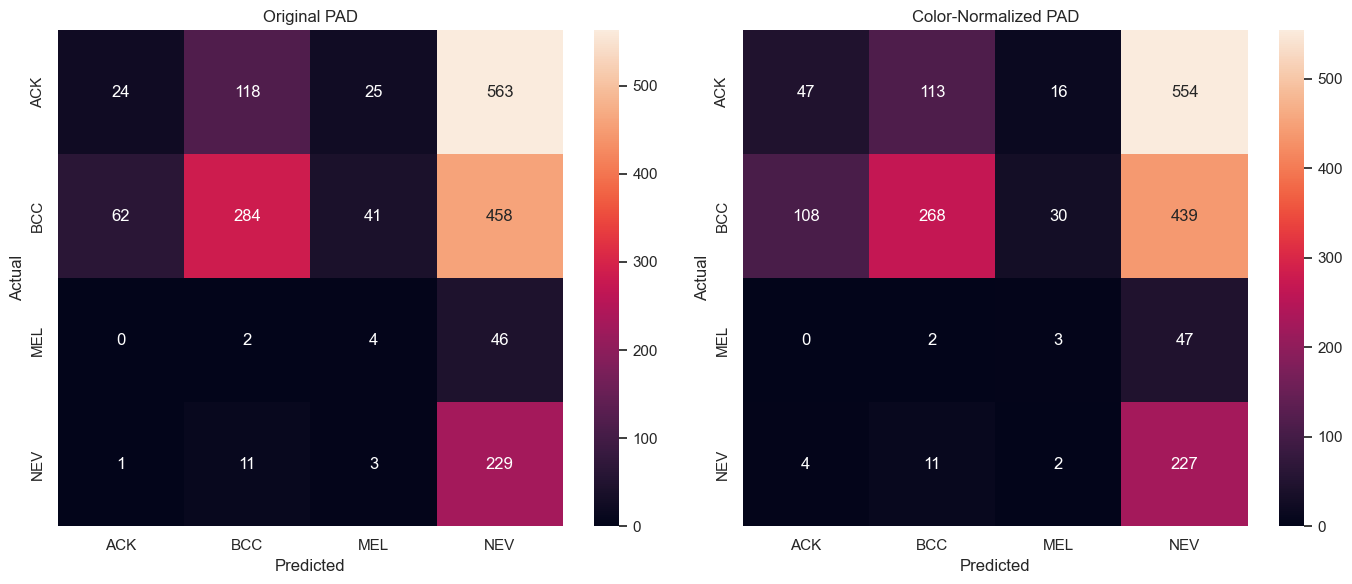

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    orig_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0]
)
axes[0].set_title("Original PAD")

sns.heatmap(
    norm_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1]
)
axes[1].set_title("Color-Normalized PAD")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
results_dict = {
    "source_dataset_mean_rgb": ham_mean_rgb.tolist(),
    "source_dataset_std_rgb": ham_std_rgb.tolist(),
    "target_dataset_mean_rgb": pad_mean_rgb.tolist(),
    "target_dataset_std_rgb": pad_std_rgb.tolist(),
    "original_pad": {
        "accuracy": float(orig_acc_m),
        "precision": float(orig_prec),
        "recall": float(orig_rec),
        "f1": float(orig_f1),
        "auc": float(orig_auc)
    },
    "color_normalized_pad": {
        "accuracy": float(norm_acc_m),
        "precision": float(norm_prec),
        "recall": float(norm_rec),
        "f1": float(norm_f1),
        "auc": float(norm_auc)
    }
}

with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results_dict, f, indent=2)

print("Saved results.json")

Saved results.json


In [19]:
pad_norm[["img_id", "label", "image_path"]].to_csv(
    OUT_DIR / "color_normalized_pad_paths.csv",
    index=False
)

print("Saved normalized image path mapping.")

Saved normalized image path mapping.


In [20]:
print("\n--- COLOR NORMALIZATION REPORT ---")
print("HAM mean RGB:", tuple(round(x, 2) for x in ham_mean_rgb))
print("PAD mean RGB:", tuple(round(x, 2) for x in pad_mean_rgb))
print(f"Original PAD F1: {orig_f1:.4f}")
print(f"Color-Normalized PAD F1: {norm_f1:.4f}")
print(f"F1 gain: {norm_f1 - orig_f1:.4f}")
print(f"Original PAD AUC: {orig_auc:.4f}")
print(f"Color-Normalized PAD AUC: {norm_auc:.4f}")


--- COLOR NORMALIZATION REPORT ---
HAM mean RGB: (196.68, 138.93, 144.81)
PAD mean RGB: (169.9, 132.98, 117.59)
Original PAD F1: 0.2177
Color-Normalized PAD F1: 0.2243
F1 gain: 0.0065
Original PAD AUC: 0.6664
Color-Normalized PAD AUC: 0.6665
